In [1]:
import sys
print(sys.version)

3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:36:49) [MSC v.1944 64 bit (AMD64)]


In [2]:
from surprise import Reader,Dataset,SVD,SVDpp,NMF,KNNWithMeans,KNNBasic,KNNWithZScore,KNNBaseline
from surprise.model_selection import train_test_split
from surprise import accuracy
import pandas as pd

In [3]:
reader = Reader(rating_scale=(1, 5))
df = pd.read_csv('Data/Clean_reviewers_data_without_comment.csv')
data = Dataset.load_from_df(df[['user_id', 'book_id', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=21)

# Memory-based : user-based, item-based

In [6]:
from tqdm import tqdm







sim_options_user = {'name': 'cosine', 'user_based': True}
sim_options_item = {'name': 'cosine', 'user_based': False}

algo_mean_user = KNNWithMeans(sim_options=sim_options_user, verbose=False)
algo_mean_item = KNNWithMeans(sim_options=sim_options_item, verbose=False)
algo_mean_user.fit(trainset)
algo_mean_item.fit(trainset)

algo_basic_user = KNNBasic(sim_options=sim_options_user, verbose=False)
algo_basic_item = KNNBasic(sim_options=sim_options_item, verbose=False)
algo_basic_user.fit(trainset)
algo_basic_item.fit(trainset)

algo_baseline_user = KNNBaseline(sim_options=sim_options_user, verbose=False)
algo_baseline_item = KNNBaseline(sim_options=sim_options_item, verbose=False)
algo_baseline_user.fit(trainset)
algo_baseline_item.fit(trainset)

algo_zscore_user = KNNWithZScore(sim_options=sim_options_user, verbose=False)
algo_zscore_item = KNNWithZScore(sim_options=sim_options_item, verbose=False)
algo_zscore_user.fit(trainset)
algo_zscore_item.fit(trainset)

KNNWithMeans

In [7]:
means_results = []
for k in tqdm(range(1, 51), desc="KNNWithMeans"):
    algo_mean_user.k = k
    algo_mean_item.k = k
    preds_user = algo_mean_user.test(testset)
    preds_item = algo_mean_item.test(testset)
    rmse_u = accuracy.rmse(preds_user, verbose=False)
    rmse_i = accuracy.rmse(preds_item, verbose=False)
    means_results.append({
        'K'          : k,
        '[USER] RMSE': rmse_u,
        '[USER] MSE' : rmse_u ** 2,
        '[USER] MAE' : accuracy.mae(preds_user, verbose=False),
        '[ITEM] RMSE': rmse_i,
        '[ITEM] MSE' : rmse_i ** 2,
        '[ITEM] MAE' : accuracy.mae(preds_item, verbose=False),
    })
df_mean_results = pd.DataFrame(means_results).set_index('K')
display(df_mean_results)

KNNWithMeans: 100%|████████████████████████████████████████████████████████████████████| 50/50 [38:54<00:00, 46.69s/it]


,[USER] RMSE,[USER] MSE,[USER] MAE,[ITEM] RMSE,[ITEM] MSE,[ITEM] MAE
K,,,,,,
1,1.252405,1.568519,0.931055,1.218810,1.485497,0.878777
2,1.122273,1.259496,0.848009,1.082299,1.171371,0.806242
3,1.076049,1.157881,0.816623,1.031892,1.064800,0.776458
4,1.050653,1.103871,0.799290,1.006323,1.012686,0.762245
5,1.035810,1.072903,0.789085,0.991636,0.983341,0.752523
6,1.025293,1.051226,0.781022,0.982991,0.966272,0.747387
7,1.016978,1.034243,0.775513,0.975896,0.952372,0.742888
8,1.010562,1.021236,0.771431,0.971675,0.944152,0.740393
9,1.005650,1.011332,0.768062,0.968719,0.938416,0.738824


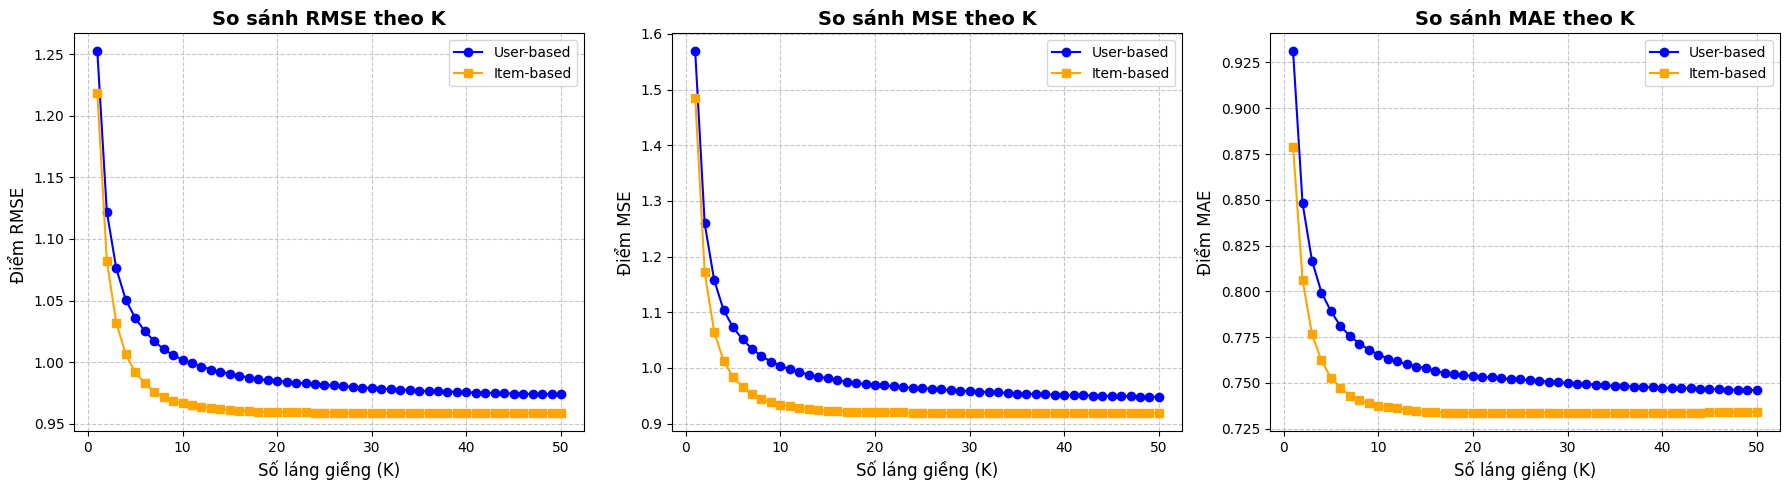

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. BIỂU ĐỒ RMSE 
axes[0].plot(df_mean_results.index, df_mean_results['[USER] RMSE'], marker='o', color='blue', label='User-based')
axes[0].plot(df_mean_results.index, df_mean_results['[ITEM] RMSE'], marker='s', color='orange', label='Item-based')
axes[0].set_title('So sánh RMSE theo K', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[0].set_ylabel('Điểm RMSE ', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. BIỂU ĐỒ MSE
axes[1].plot(df_mean_results.index, df_mean_results['[USER] MSE'], marker='o', color='blue', label='User-based')
axes[1].plot(df_mean_results.index, df_mean_results['[ITEM] MSE'], marker='s', color='orange', label='Item-based')
axes[1].set_title('So sánh MSE theo K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[1].set_ylabel('Điểm MSE', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. BIỂU ĐỒ MAE
axes[2].plot(df_mean_results.index, df_mean_results['[USER] MAE'], marker='o', color='blue', label='User-based')
axes[2].plot(df_mean_results.index, df_mean_results['[ITEM] MAE'], marker='s', color='orange', label='Item-based')
axes[2].set_title('So sánh MAE theo K', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[2].set_ylabel('Điểm MAE', fontsize=12)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

KNNBaseline

In [11]:
baseline_results = []
for k in tqdm(range(1, 51), desc="KNNBaseline"):
    algo_baseline_user.k = k
    algo_baseline_item.k = k
    preds_user = algo_baseline_user.test(testset)
    preds_item = algo_baseline_item.test(testset)
    rmse_u = accuracy.rmse(preds_user, verbose=False)
    rmse_i = accuracy.rmse(preds_item, verbose=False)
    baseline_results.append({
        'K'          : k,
        '[USER] RMSE': rmse_u,
        '[USER] MSE' : rmse_u ** 2,
        '[USER] MAE' : accuracy.mae(preds_user, verbose=False),
        '[ITEM] RMSE': rmse_i,
        '[ITEM] MSE' : rmse_i ** 2,
        '[ITEM] MAE' : accuracy.mae(preds_item, verbose=False),
    })
df_baseline_results = pd.DataFrame(baseline_results).set_index('K')
display(df_baseline_results)

KNNBaseline: 100%|█████████████████████████████████████████████████████████████████████| 50/50 [41:05<00:00, 49.32s/it]


,[USER] RMSE,[USER] MSE,[USER] MAE,[ITEM] RMSE,[ITEM] MSE,[ITEM] MAE
K,,,,,,
1,1.289374,1.662484,0.954055,1.218048,1.483641,0.876697
2,1.133676,1.285221,0.861669,1.080978,1.168513,0.804288
3,1.078541,1.163251,0.826163,1.030585,1.062106,0.774618
4,1.048560,1.099477,0.806369,1.004989,1.010004,0.760607
5,1.030844,1.062640,0.794480,0.990326,0.980746,0.750975
6,1.018300,1.036935,0.785616,0.981696,0.963728,0.746015
7,1.008493,1.017058,0.779298,0.974608,0.949860,0.741628
8,1.001063,1.002128,0.774632,0.970399,0.941674,0.739177
9,0.995206,0.990435,0.771066,0.967434,0.935928,0.737689


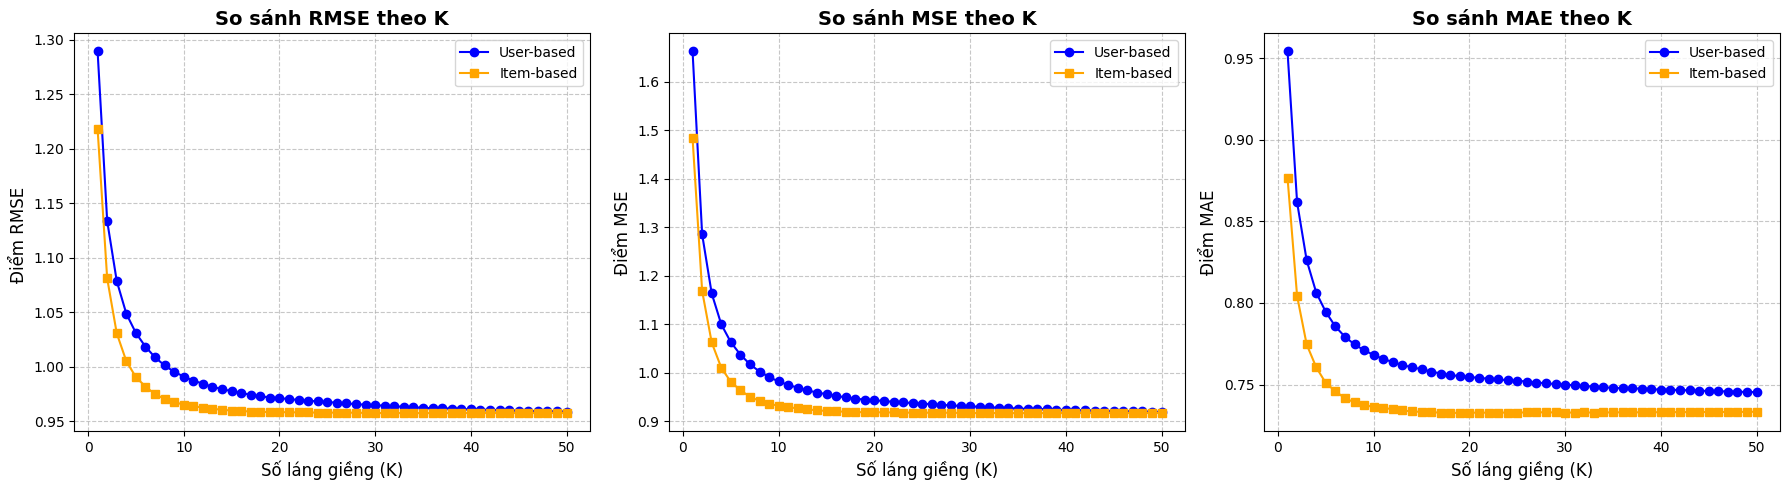

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. BIỂU ĐỒ RMSE 
axes[0].plot(df_baseline_results.index, df_baseline_results['[USER] RMSE'], marker='o', color='blue', label='User-based')
axes[0].plot(df_baseline_results.index, df_baseline_results['[ITEM] RMSE'], marker='s', color='orange', label='Item-based')
axes[0].set_title('So sánh RMSE theo K', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[0].set_ylabel('Điểm RMSE ', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. BIỂU ĐỒ MSE
axes[1].plot(df_baseline_results.index, df_baseline_results['[USER] MSE'], marker='o', color='blue', label='User-based')
axes[1].plot(df_baseline_results.index, df_baseline_results['[ITEM] MSE'], marker='s', color='orange', label='Item-based')
axes[1].set_title('So sánh MSE theo K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[1].set_ylabel('Điểm MSE', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. BIỂU ĐỒ MAE
axes[2].plot(df_baseline_results.index, df_baseline_results['[USER] MAE'], marker='o', color='blue', label='User-based')
axes[2].plot(df_baseline_results.index, df_baseline_results['[ITEM] MAE'], marker='s', color='orange', label='Item-based')
axes[2].set_title('So sánh MAE theo K', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[2].set_ylabel('Điểm MAE', fontsize=12)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

KNNBasic

In [21]:
basic_results = []
for k in tqdm(range(1, 51), desc="KNNBasic"):
    algo_basic_user.k = k
    algo_basic_item.k = k
    preds_user = algo_basic_user.test(testset)
    preds_item = algo_basic_item.test(testset)
    rmse_u = accuracy.rmse(preds_user, verbose=False)
    rmse_i = accuracy.rmse(preds_item, verbose=False)
    basic_results.append({
        'K'          : k,
        '[USER] RMSE': rmse_u,
        '[USER] MSE' : rmse_u ** 2,
        '[USER] MAE' : accuracy.mae(preds_user, verbose=False),
        '[ITEM] RMSE': rmse_i,
        '[ITEM] MSE' : rmse_i ** 2,
        '[ITEM] MAE' : accuracy.mae(preds_item, verbose=False),
    })
df_basic_results = pd.DataFrame(basic_results).set_index('K')
display(df_basic_results)

KNNBasic: 100%|████████████████████████████████████████████████████████████████████████| 50/50 [37:47<00:00, 45.36s/it]


,[USER] RMSE,[USER] MSE,[USER] MAE,[ITEM] RMSE,[ITEM] MSE,[ITEM] MAE
K,,,,,,
1,1.410698,1.990069,1.006923,1.324158,1.753394,0.902212
2,1.221655,1.492441,0.917245,1.156093,1.336550,0.836592
3,1.154569,1.333029,0.882610,1.097656,1.204848,0.810125
4,1.119273,1.252773,0.862956,1.069288,1.143377,0.799555
5,1.098190,1.206020,0.850517,1.053460,1.109778,0.792293
6,1.083141,1.173195,0.841472,1.044075,1.090092,0.789209
7,1.071959,1.149096,0.834339,1.037178,1.075738,0.786866
8,1.063374,1.130764,0.829165,1.033262,1.067630,0.785781
9,1.056552,1.116301,0.825118,1.030178,1.061267,0.785391


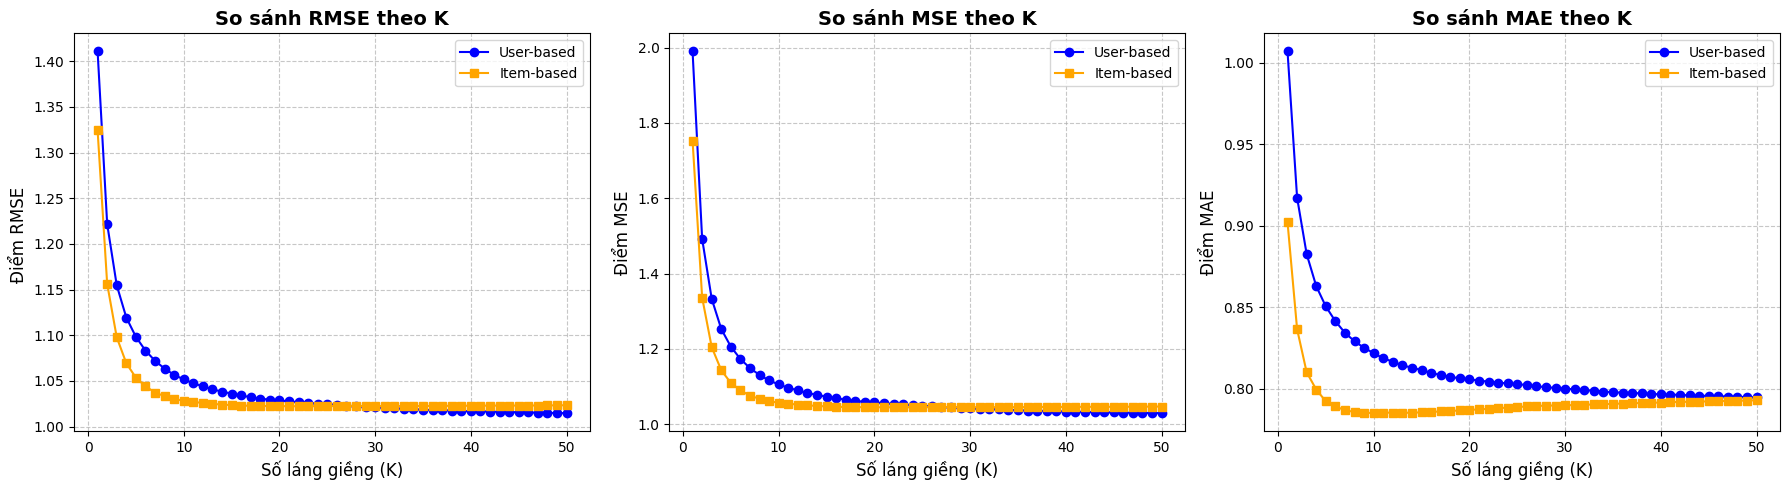

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. BIỂU ĐỒ RMSE 
axes[0].plot(df_basic_results.index, df_basic_results['[USER] RMSE'], marker='o', color='blue', label='User-based')
axes[0].plot(df_basic_results.index, df_basic_results['[ITEM] RMSE'], marker='s', color='orange', label='Item-based')
axes[0].set_title('So sánh RMSE theo K', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[0].set_ylabel('Điểm RMSE ', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. BIỂU ĐỒ MSE
axes[1].plot(df_basic_results.index, df_basic_results['[USER] MSE'], marker='o', color='blue', label='User-based')
axes[1].plot(df_basic_results.index, df_basic_results['[ITEM] MSE'], marker='s', color='orange', label='Item-based')
axes[1].set_title('So sánh MSE theo K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[1].set_ylabel('Điểm MSE', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. BIỂU ĐỒ MAE
axes[2].plot(df_basic_results.index, df_basic_results['[USER] MAE'], marker='o', color='blue', label='User-based')
axes[2].plot(df_basic_results.index, df_basic_results['[ITEM] MAE'], marker='s', color='orange', label='Item-based')
axes[2].set_title('So sánh MAE theo K', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[2].set_ylabel('Điểm MAE', fontsize=12)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

KNNWithZScore

In [18]:
zscore_results = []
for k in tqdm(range(1, 51), desc="KNNWithZScore"):
    algo_zscore_user.k = k
    algo_zscore_item.k = k
    preds_user = algo_zscore_user.test(testset)
    preds_item = algo_zscore_item.test(testset)
    rmse_u = accuracy.rmse(preds_user, verbose=False)
    rmse_i = accuracy.rmse(preds_item, verbose=False)
    zscore_results.append({
        'K'          : k,
        '[USER] RMSE': rmse_u,
        '[USER] MSE' : rmse_u ** 2,
        '[USER] MAE' : accuracy.mae(preds_user, verbose=False),
        '[ITEM] RMSE': rmse_i,
        '[ITEM] MSE' : rmse_i ** 2,
        '[ITEM] MAE' : accuracy.mae(preds_item, verbose=False),
    })
df_zscore_results = pd.DataFrame(zscore_results).set_index('K')
display(df_zscore_results)

KNNWithZScore: 100%|███████████████████████████████████████████████████████████████████| 50/50 [49:09<00:00, 58.98s/it]


,[USER] RMSE,[USER] MSE,[USER] MAE,[ITEM] RMSE,[ITEM] MSE,[ITEM] MAE
K,,,,,,
1,1.262013,1.592677,0.926075,1.244041,1.547638,0.890450
2,1.131443,1.280163,0.844151,1.103168,1.216980,0.813357
3,1.083117,1.173143,0.813593,1.048369,1.099079,0.781465
4,1.056127,1.115405,0.796649,1.019248,1.038867,0.765558
5,1.039964,1.081526,0.786798,1.001809,1.003621,0.754878
6,1.029410,1.059684,0.779262,0.991203,0.982484,0.749013
7,1.020584,1.041591,0.773734,0.982659,0.965619,0.743784
8,1.013964,1.028123,0.769980,0.977474,0.955455,0.740930
9,1.009106,1.018295,0.767103,0.973683,0.948059,0.739058


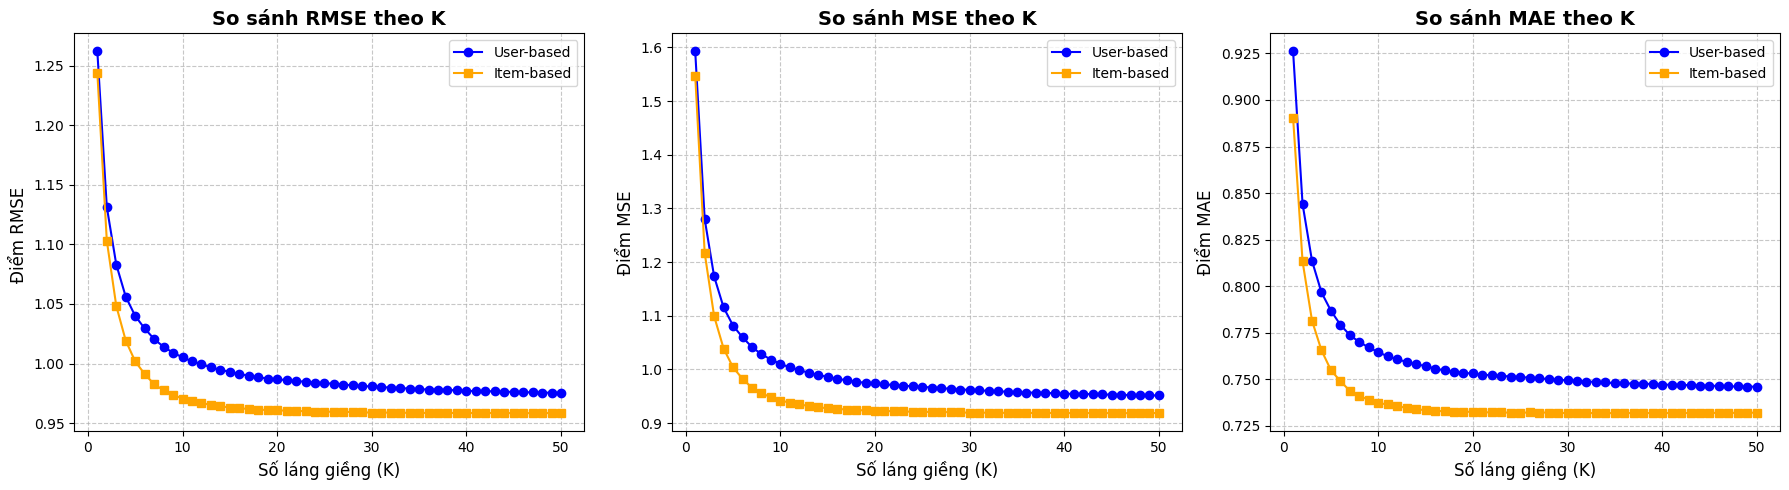

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. BIỂU ĐỒ RMSE 
axes[0].plot(df_zscore_results.index, df_zscore_results['[USER] RMSE'], marker='o', color='blue', label='User-based')
axes[0].plot(df_zscore_results.index, df_zscore_results['[ITEM] RMSE'], marker='s', color='orange', label='Item-based')
axes[0].set_title('So sánh RMSE theo K', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[0].set_ylabel('Điểm RMSE ', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. BIỂU ĐỒ MSE
axes[1].plot(df_zscore_results.index, df_zscore_results['[USER] MSE'], marker='o', color='blue', label='User-based')
axes[1].plot(df_zscore_results.index, df_zscore_results['[ITEM] MSE'], marker='s', color='orange', label='Item-based')
axes[1].set_title('So sánh MSE theo K', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[1].set_ylabel('Điểm MSE', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. BIỂU ĐỒ MAE
axes[2].plot(df_zscore_results.index, df_zscore_results['[USER] MAE'], marker='o', color='blue', label='User-based')
axes[2].plot(df_zscore_results.index, df_zscore_results['[ITEM] MAE'], marker='s', color='orange', label='Item-based')
axes[2].set_title('So sánh MAE theo K', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Số láng giềng (K)', fontsize=12)
axes[2].set_ylabel('Điểm MAE', fontsize=12)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [23]:
df_compare = pd.DataFrame({
    'KNNWithMeans User' : df_mean_results['[USER] RMSE'],
    'KNNWithMeans Item' : df_mean_results['[ITEM] RMSE'],
    'KNNBasic User'     : df_basic_results['[USER] RMSE'],
    'KNNBasic Item'     : df_basic_results['[ITEM] RMSE'],
    'KNNBaseline User'  : df_baseline_results['[USER] RMSE'],
    'KNNBaseline Item'  : df_baseline_results['[ITEM] RMSE'],
    'KNNWithZScore User': df_zscore_results['[USER] RMSE'],
    'KNNWithZScore Item': df_zscore_results['[ITEM] RMSE'],
})
display(df_compare)

,KNNWithMeans User,KNNWithMeans Item,KNNBasic User,KNNBasic Item,KNNBaseline User,KNNBaseline Item,KNNWithZScore User,KNNWithZScore Item
K,,,,,,,,
1,1.252405,1.218810,1.410698,1.324158,1.289374,1.218048,1.262013,1.244041
2,1.122273,1.082299,1.221655,1.156093,1.133676,1.080978,1.131443,1.103168
3,1.076049,1.031892,1.154569,1.097656,1.078541,1.030585,1.083117,1.048369
4,1.050653,1.006323,1.119273,1.069288,1.048560,1.004989,1.056127,1.019248
5,1.035810,0.991636,1.098190,1.053460,1.030844,0.990326,1.039964,1.001809
6,1.025293,0.982991,1.083141,1.044075,1.018300,0.981696,1.029410,0.991203
7,1.016978,0.975896,1.071959,1.037178,1.008493,0.974608,1.020584,0.982659
8,1.010562,0.971675,1.063374,1.033262,1.001063,0.970399,1.013964,0.977474
9,1.005650,0.968719,1.056552,1.030178,0.995206,0.967434,1.009106,0.973683


In [35]:
# In tiêu đề bảng
print(f"{'Algorithm':<25} {'Based':<8} {'K ':>6}  {'MIN RMSE':>8}")
print("-" * 55)

for col in df_compare.columns:
    best_k    = df_compare[col].idxmin()
    min_rmse  = df_compare[col].min()
    parts = col.rsplit(' ', 1)        
    model = parts[0]
    side  = parts[1]
    print(f"{model:<25} {side:<8} {best_k:>6}  {min_rmse:>8.4f}")

print("=" * 55)

best_col  = df_compare.min().idxmin()
best_k    = df_compare[best_col].idxmin()
best_rmse = df_compare[best_col].min()
print(f"TỐT NHẤT TỔNG THỂ: {best_col} với K = {best_k} và RMSE = {best_rmse}")

Algorithm                 Based        K   MIN RMSE
-------------------------------------------------------
KNNWithMeans              User         50    0.9736
KNNWithMeans              Item         35    0.9585
KNNBasic                  User         50    1.0146
KNNBasic                  Item         22    1.0222
KNNBaseline               User         50    0.9588
KNNBaseline               Item         35    0.9573
KNNWithZScore             User         50    0.9754
KNNWithZScore             Item         47    0.9583
TỐT NHẤT TỔNG THỂ: KNNBaseline Item với K = 35 và RMSE = 0.957272012058111


# Model-based

In [40]:
from surprise import SVD, SVDpp, NMF, BaselineOnly, accuracy
from tqdm import tqdm

results_dict = {'SVD': [], 'SVD++': [], 'NMF': []}
n_factors_list = range(2, 51, 2)

# BaselineOnly
algo_baseline = BaselineOnly(verbose=False)
algo_baseline.fit(trainset)
preds_baseline = algo_baseline.test(testset)
baseline_rmse = accuracy.rmse(preds_baseline, verbose=False)
baseline_mae  = accuracy.mae(preds_baseline,  verbose=False)
baseline_mse  = baseline_rmse ** 2
print(f"Baseline | RMSE: {baseline_rmse} | MSE: {baseline_mse} | MAE: {baseline_mae}")

# SVD, SVD++, NMF loop theo n_factors
for n in tqdm(n_factors_list, desc="Processing"):
    for name, algo in [
        ('SVD',   SVD(n_factors=n,   random_state=21)),
        ('SVD++', SVDpp(n_factors=n, random_state=21)),
        ('NMF',   NMF(n_factors=n,   random_state=21)),
    ]:
        algo.fit(trainset)
        predictions = algo.test(testset)
        rmse = accuracy.rmse(predictions, verbose=False)
        mae  = accuracy.mae(predictions,  verbose=False)
        results_dict[name].append({
            'n_factors': n,
            'RMSE': rmse,
            'MSE' : rmse ** 2,
            'MAE' : mae
        })

df_svd        = pd.DataFrame(results_dict['SVD'])
df_svdplusplus = pd.DataFrame(results_dict['SVD++'])
df_nmf        = pd.DataFrame(results_dict['NMF'])

# Gộp bảng
df_rmse = pd.DataFrame({
    'n_factors': df_svd['n_factors'],
    'SVD'     : df_svd['RMSE'],
    'SVD++'   : df_svdplusplus['RMSE'],
    'NMF'     : df_nmf['RMSE'],
    'Baseline': baseline_rmse   
})
df_mae = pd.DataFrame({
    'n_factors': df_svd['n_factors'],
    'SVD'     : df_svd['MAE'],
    'SVD++'   : df_svdplusplus['MAE'],
    'NMF'     : df_nmf['MAE'],
    'Baseline': baseline_mae
})
df_mse = pd.DataFrame({
    'n_factors': df_svd['n_factors'],
    'SVD'     : df_svd['MSE'],
    'SVD++'   : df_svdplusplus['MSE'],
    'NMF'     : df_nmf['MSE'],
    'Baseline': baseline_mse
})
display(df_rmse)
display(df_mae)
display(df_mse)





Baseline | RMSE: 0.955838523267334 | MSE: 0.9136272825618778 | MAE: 0.7468145606360023


Processing: 100%|██████████████████████████████████████████████████████████████████████| 25/25 [27:46<00:00, 66.65s/it]


,n_factors,SVD,SVD++,NMF,Baseline
0,2,0.950461,0.935846,1.423981,0.955839
1,4,0.950582,0.935032,1.252918,0.955839
2,6,0.950871,0.935357,1.150346,0.955839
3,8,0.951279,0.936790,1.087673,0.955839
4,10,0.950006,0.936440,1.053411,0.955839
5,12,0.951331,0.937937,1.029540,0.955839
6,14,0.952763,0.940771,1.013458,0.955839
7,16,0.952636,0.941473,1.005395,0.955839
8,18,0.952245,0.940544,1.007605,0.955839
9,20,0.951318,0.939078,1.001628,0.955839


,n_factors,SVD,SVD++,NMF,Baseline
0,2,0.737254,0.718134,1.255144,0.746815
1,4,0.737286,0.716842,1.078130,0.746815
2,6,0.737333,0.716180,0.965709,0.746815
3,8,0.737452,0.716877,0.893411,0.746815
4,10,0.736550,0.716857,0.848930,0.746815
5,12,0.737768,0.717836,0.816704,0.746815
6,14,0.738697,0.719696,0.790907,0.746815
7,16,0.738384,0.719160,0.773112,0.746815
8,18,0.737876,0.718810,0.766651,0.746815
9,20,0.737616,0.717977,0.754054,0.746815


,n_factors,SVD,SVD++,NMF,Baseline
0,2,0.903377,0.875808,2.027722,0.913627
1,4,0.903606,0.874286,1.569805,0.913627
2,6,0.904155,0.874893,1.323297,0.913627
3,8,0.904932,0.877575,1.183033,0.913627
4,10,0.902512,0.876919,1.109675,0.913627
5,12,0.905031,0.879725,1.059952,0.913627
6,14,0.907757,0.885050,1.027096,0.913627
7,16,0.907515,0.886371,1.010818,0.913627
8,18,0.906770,0.884622,1.015268,0.913627
9,20,0.905007,0.881868,1.003258,0.913627


SVD:    RMSE chạm đáy tại 0.9500062301370356   (n_factors = 10)
SVD++:  RMSE chạm đáy tại 0.935032394694461 (n_factors = 4)
NMF:    RMSE chạm đáy tại 1.0016275943979187   (n_factors = 20)
Baseline:               0.955838523267334 


In [42]:
# Tìm best n_factors 
temp_df = df_rmse.set_index('n_factors')
best_n_svd    = temp_df['SVD'].idxmin()
best_n_svdpp  = temp_df['SVD++'].idxmin()
best_n_nmf    = temp_df['NMF'].idxmin()

print(f"SVD:    RMSE chạm đáy tại {temp_df['SVD'].min()} (n_factors = {best_n_svd})")
print(f"SVD++:  RMSE chạm đáy tại {temp_df['SVD++'].min()} (n_factors = {best_n_svdpp})")
print(f"NMF:    RMSE chạm đáy tại {temp_df['NMF'].min()} (n_factors = {best_n_nmf})")
print(f"Baseline: {baseline_rmse} ")

SVD:    RMSE chạm đáy tại 0.9500062301370356 (n_factors = 10)
SVD++:  RMSE chạm đáy tại 0.935032394694461 (n_factors = 4)
NMF:    RMSE chạm đáy tại 1.0016275943979187 (n_factors = 20)
Baseline: 0.955838523267334 


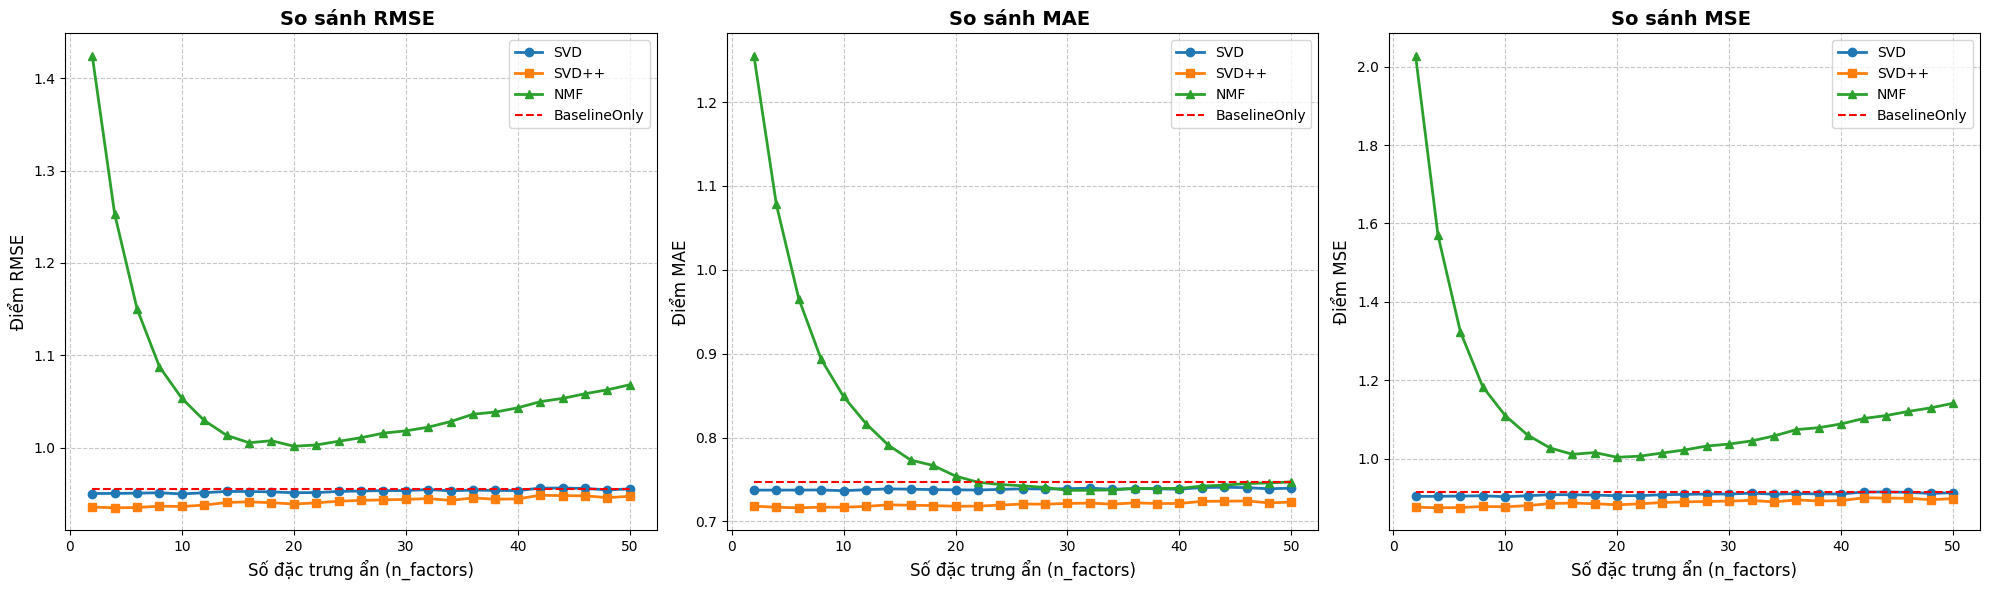

In [49]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 3, figsize=(20, 6))


# 1. BIỂU ĐỒ RMSE (Root Mean Squared Error)

axes[0].plot(df_rmse['n_factors'], df_rmse['SVD'], marker='o', label='SVD', linewidth=2)
axes[0].plot(df_rmse['n_factors'], df_rmse['SVD++'], marker='s', label='SVD++', linewidth=2)
axes[0].plot(df_rmse['n_factors'], df_rmse['NMF'], marker='^', label='NMF', linewidth=2)
axes[0].plot(df_rmse['n_factors'], df_rmse['Baseline'], linestyle='--', color='red', label='BaselineOnly')

axes[0].set_title('So sánh RMSE ', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số đặc trưng ẩn (n_factors)', fontsize=12)
axes[0].set_ylabel('Điểm RMSE', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)


# 2. BIỂU ĐỒ MAE (Mean Absolute Error)

axes[1].plot(df_mae['n_factors'], df_mae['SVD'], marker='o', label='SVD', linewidth=2)
axes[1].plot(df_mae['n_factors'], df_mae['SVD++'], marker='s', label='SVD++', linewidth=2)
axes[1].plot(df_mae['n_factors'], df_mae['NMF'], marker='^', label='NMF', linewidth=2)
axes[1].plot(df_mae['n_factors'], df_mae['Baseline'], linestyle='--', color='red', label='BaselineOnly')

axes[1].set_title('So sánh MAE ', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Số đặc trưng ẩn (n_factors)', fontsize=12)
axes[1].set_ylabel('Điểm MAE', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)


# 3. BIỂU ĐỒ MSE (Mean Squared Error)

axes[2].plot(df_mse['n_factors'], df_mse['SVD'], marker='o', label='SVD', linewidth=2)
axes[2].plot(df_mse['n_factors'], df_mse['SVD++'], marker='s', label='SVD++', linewidth=2)
axes[2].plot(df_mse['n_factors'], df_mse['NMF'], marker='^', label='NMF', linewidth=2)
axes[2].plot(df_mse['n_factors'], df_mse['Baseline'], linestyle='--', color='red', label='BaselineOnly')

axes[2].set_title('So sánh MSE ', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Số đặc trưng ẩn (n_factors)', fontsize=12)
axes[2].set_ylabel('Điểm MSE', fontsize=12)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

# Choose the best model

In [50]:
# Train final model với best n_factors 
full_trainset = data.build_full_trainset()
final_model = SVDpp(n_factors=best_n_svdpp, random_state=21)  
final_model.fit(full_trainset)

In [51]:
import pickle

with open('final_svdpp_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

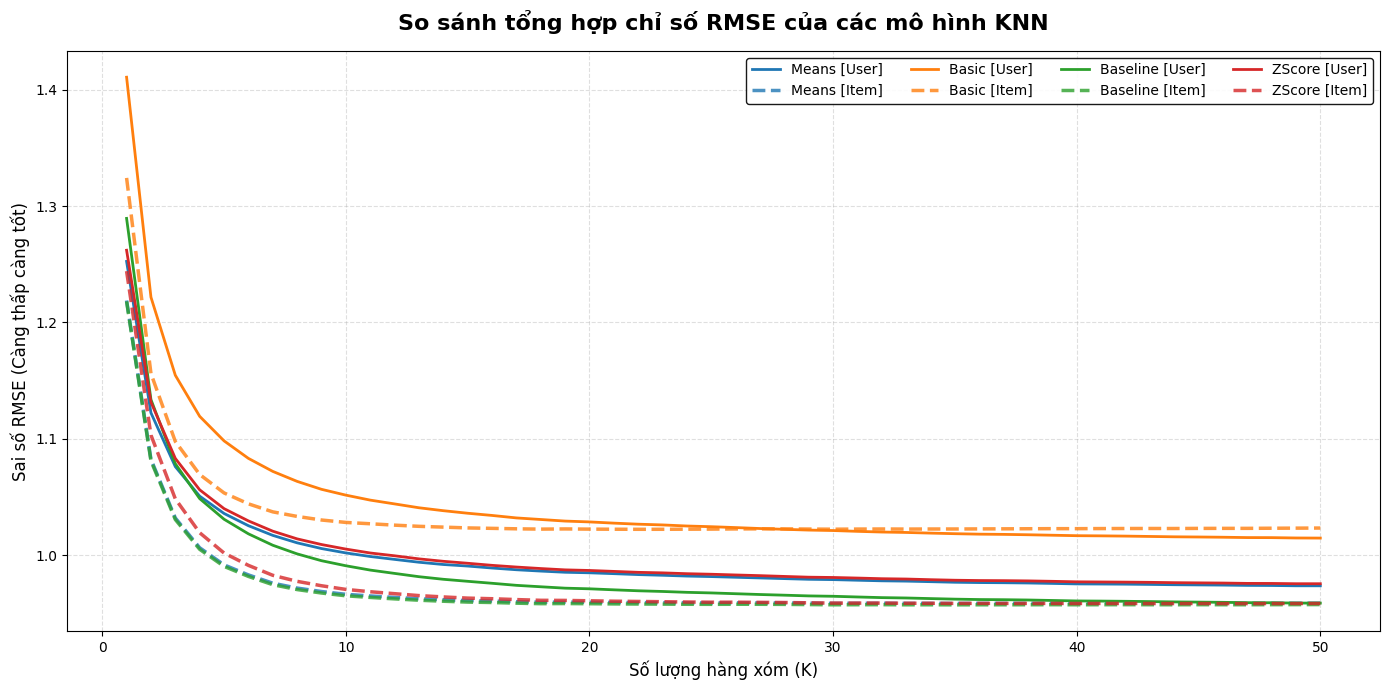

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7)) # Phóng to biểu đồ ra một chút cho thoáng

# 1. Định nghĩa bảng màu (Tableau 10 chuẩn mực)
c_means    = '#1f77b4'  # Xanh dương
c_basic    = '#ff7f0e'  # Cam
c_baseline = '#2ca02c'  # Xanh lá
c_zscore   = '#d62728'  # Đỏ

# 2. KNN With Means (Màu Xanh dương)
ax.plot(df_mean_results.index, df_mean_results['[USER] RMSE'], color=c_means, linestyle='-',  linewidth=2, label='Means [User]')
ax.plot(df_mean_results.index, df_mean_results['[ITEM] RMSE'], color=c_means, linestyle='--', linewidth=2.5, alpha=0.8, label='Means [Item]')

# 3. KNN Basic (Màu Cam)
ax.plot(df_basic_results.index, df_basic_results['[USER] RMSE'], color=c_basic, linestyle='-',  linewidth=2, label='Basic [User]')
ax.plot(df_basic_results.index, df_basic_results['[ITEM] RMSE'], color=c_basic, linestyle='--', linewidth=2.5, alpha=0.8, label='Basic [Item]')

# 4. KNN Baseline (Màu Xanh lá)
ax.plot(df_baseline_results.index, df_baseline_results['[USER] RMSE'], color=c_baseline, linestyle='-',  linewidth=2, label='Baseline [User]')
ax.plot(df_baseline_results.index, df_baseline_results['[ITEM] RMSE'], color=c_baseline, linestyle='--', linewidth=2.5, alpha=0.8, label='Baseline [Item]')

# 5. KNN With ZScore (Màu Đỏ)
ax.plot(df_zscore_results.index, df_zscore_results['[USER] RMSE'], color=c_zscore, linestyle='-',  linewidth=2, label='ZScore [User]')
ax.plot(df_zscore_results.index, df_zscore_results['[ITEM] RMSE'], color=c_zscore, linestyle='--', linewidth=2.5, alpha=0.8, label='ZScore [Item]')

# 6. Trang trí biểu đồ
ax.set_title('So sánh tổng hợp chỉ số RMSE của các mô hình KNN', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Số lượng hàng xóm (K)', fontsize=12)
ax.set_ylabel('Sai số RMSE (Càng thấp càng tốt)', fontsize=12)

# Sắp xếp lại Legend (chú thích) thành 4 cột cho gọn gàng ở góc dưới
ax.legend(ncol=4, loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')

ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

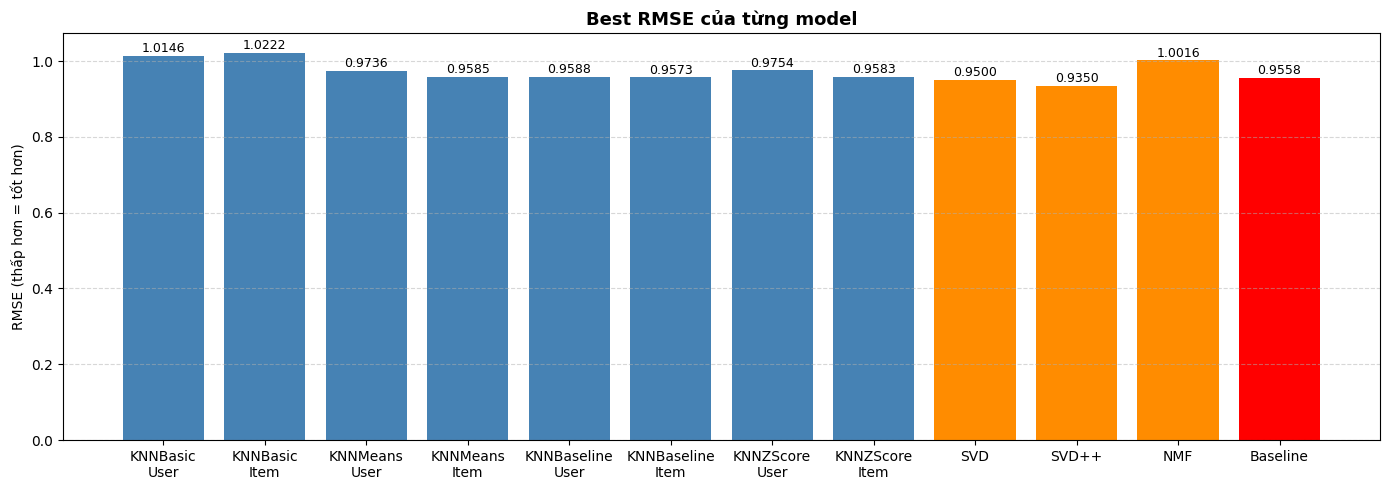

In [70]:
# Lấy RMSE tốt nhất của mỗi model
best_scores = {
    'KNNBasic\nUser'    : df_basic_results['[USER] RMSE'].min(),
    'KNNBasic\nItem'    : df_basic_results['[ITEM] RMSE'].min(),
    'KNNMeans\nUser'    : df_mean_results['[USER] RMSE'].min(),
    'KNNMeans\nItem'    : df_mean_results['[ITEM] RMSE'].min(),
    'KNNBaseline\nUser' : df_baseline_results['[USER] RMSE'].min(),
    'KNNBaseline\nItem' : df_baseline_results['[ITEM] RMSE'].min(),
    'KNNZScore\nUser'   : df_zscore_results['[USER] RMSE'].min(),
    'KNNZScore\nItem'   : df_zscore_results['[ITEM] RMSE'].min(),
    'SVD'               : temp_df['SVD'].min(),
    'SVD++'             : temp_df['SVD++'].min(),
    'NMF'               : temp_df['NMF'].min(),
    'Baseline'          : baseline_rmse,
}

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue']*8 + ['darkorange']*3 + ['red']*3
bars = ax.bar(best_scores.keys(), best_scores.values(), color=colors)

# Ghi số lên đầu mỗi cột
for bar, val in zip(bars, best_scores.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Best RMSE của từng model', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (thấp hơn = tốt hơn)')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

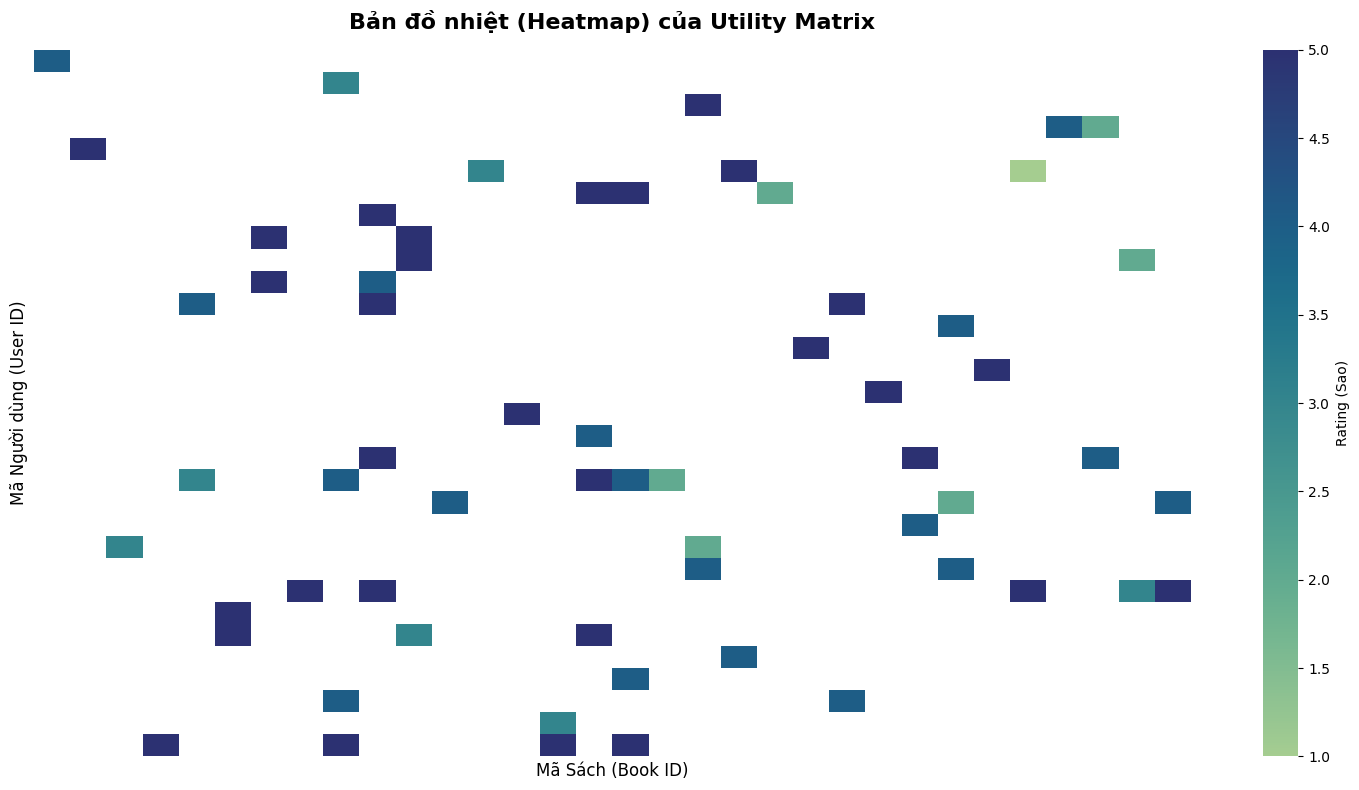

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

random_users = np.random.choice(df['user_id'].unique(), size=50, replace=False)
random_books = np.random.choice(df['book_id'].unique(), size=50, replace=False)

df_subset = df[(df['user_id'].isin(random_users)) & (df['book_id'].isin(random_books))]
utility_matrix = df_subset.pivot(index='user_id', columns='book_id', values='rating')

plt.figure(figsize=(15, 8))

sns.heatmap(utility_matrix, 
            cmap='crest',
            
            cbar_kws={'label': 'Rating (Sao)'})

plt.title('Bản đồ nhiệt (Heatmap) của Utility Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mã Sách (Book ID)', fontsize=12)
plt.ylabel('Mã Người dùng (User ID)', fontsize=12)

plt.xticks([]) 
plt.yticks([])

plt.tight_layout()
plt.show()

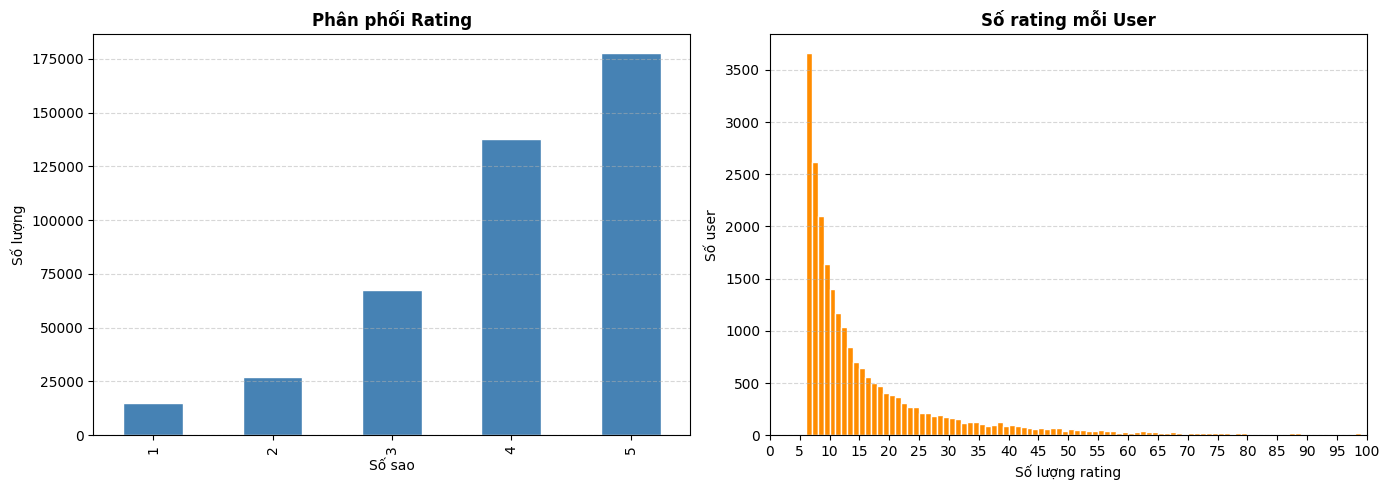

In [87]:
df = pd.read_csv('Data/Clean_reviewers_data_without_comment.csv')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối rating
df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Phân phối Rating', fontweight='bold')
axes[0].set_xlabel('Số sao')
axes[0].set_ylabel('Số lượng')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Số rating per user (long tail)
rating_per_user = df.groupby('user_id')['rating'].count()
axes[1].hist(rating_per_user, bins = np.arange(1, 102, 1), color='darkorange', edgecolor='white')
axes[1].set_title('Số rating mỗi User', fontweight='bold')
axes[1].set_xlabel('Số lượng rating')
axes[1].set_ylabel('Số user')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)
axes[1].set_xlim(0, 100)
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

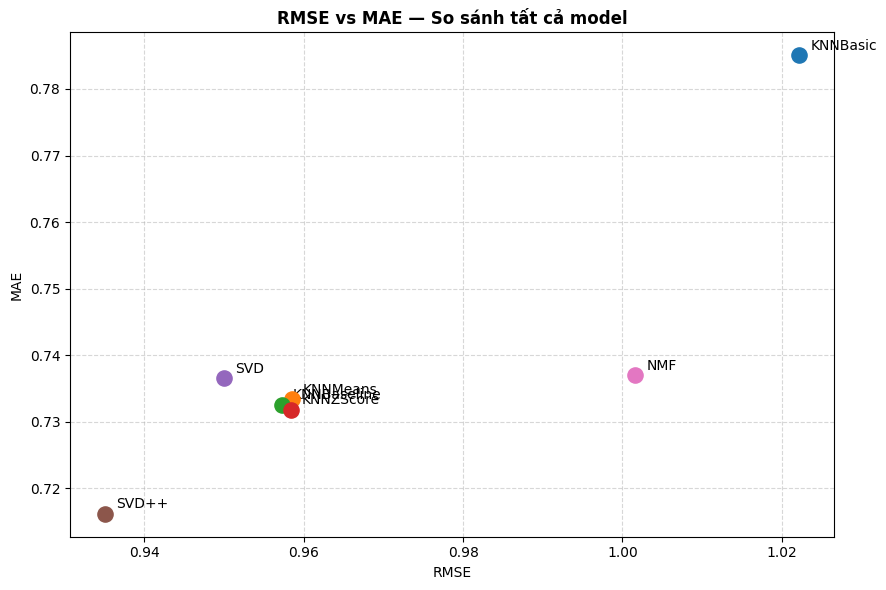

In [97]:
##### So sánh RMSE và MAE cùng lúc để thấy trade-off
models  = ['KNNBasic', 'KNNMeans', 'KNNBaseline', 'KNNZScore', 'SVD', 'SVD++', 'NMF']
rmse_scores = [
    df_basic_results['[ITEM] RMSE'].min(),
    df_mean_results['[ITEM] RMSE'].min(),
    df_baseline_results['[ITEM] RMSE'].min(),
    df_zscore_results['[ITEM] RMSE'].min(),
    temp_df['SVD'].min(),
    temp_df['SVD++'].min(),
    temp_df['NMF'].min(),
]
mae_scores = [
    df_basic_results['[ITEM] MAE'].min(),
    df_mean_results['[ITEM] MAE'].min(),
    df_baseline_results['[ITEM] MAE'].min(),
    df_zscore_results['[ITEM] MAE'].min(),
    df_svd['MAE'].min(),
    df_svdplusplus['MAE'].min(),
    df_nmf['MAE'].min(),
]

fig, ax = plt.subplots(figsize=(9, 6))
for m, r, mae in zip(models, rmse_scores, mae_scores):
    ax.scatter(r, mae, s=120, zorder=5)
    ax.annotate(m, (r, mae), textcoords='offset points',
                xytext=(8, 4), fontsize=10)

ax.set_title('RMSE vs MAE — So sánh tất cả model', fontweight='bold')
ax.set_xlabel('RMSE')
ax.set_ylabel('MAE')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

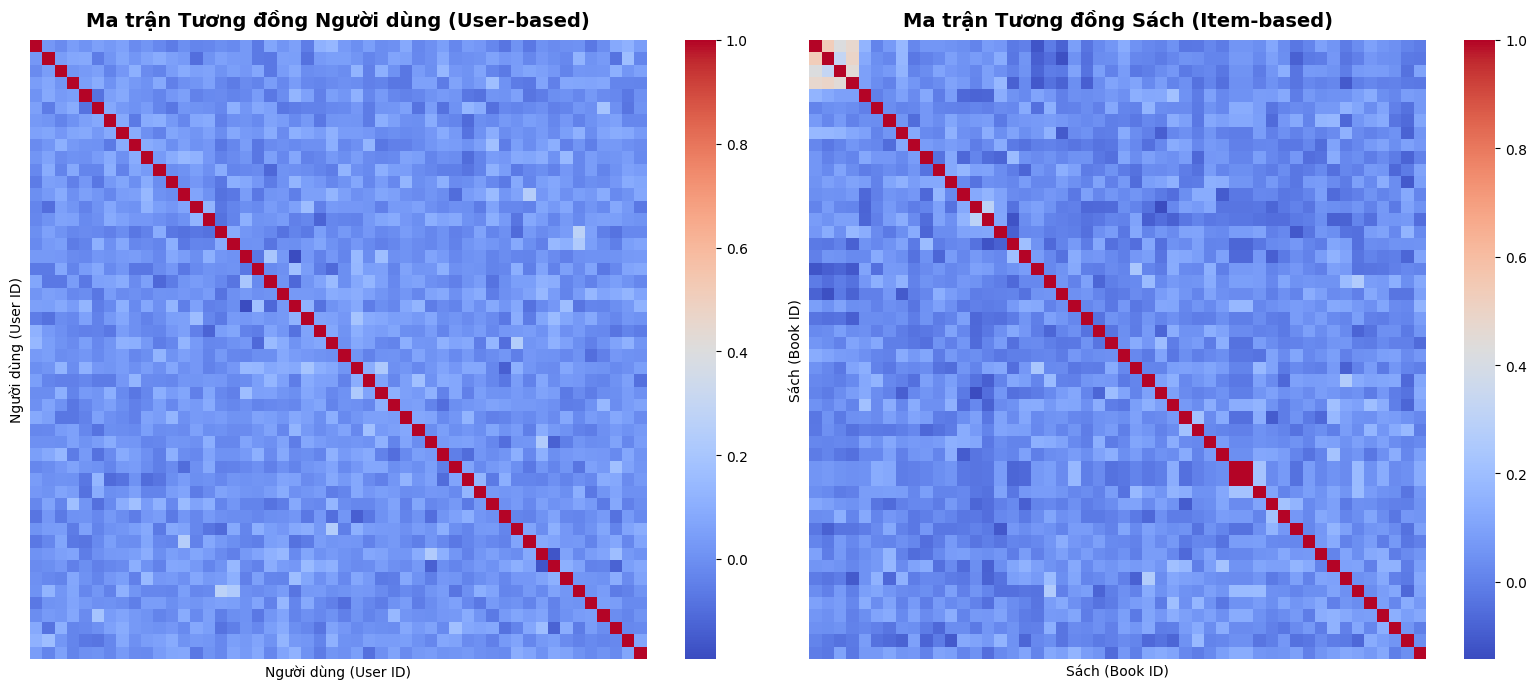

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# 1. Đọc dữ liệu
df = pd.read_csv('Data/Clean_reviewers_data_without_comment.csv')

top_users = df['user_id'].value_counts().head(500).index
top_books = df['book_id'].value_counts().head(500).index
df_subset = df[(df['user_id'].isin(top_users)) & (df['book_id'].isin(top_books))]

# 2. Tạo Utility Matrix (Sách làm dòng, User làm cột)
Y_matrix = df_subset.pivot(index='book_id', columns='user_id', values='rating')

# ==========================================
# 3. USER-BASED SIMILARITY (KNN With Means)
# ==========================================
Mean_user_rating = Y_matrix.mean(axis=0)
Normalized_utility_matrix_user = Y_matrix.sub(Mean_user_rating, axis=1)
Normalized_utility_matrix_user.fillna(0, inplace=True)

# Tính Cosine Similarity (Chuyển vị T để so sánh User với User)
user_similarity = cosine_similarity(Normalized_utility_matrix_user.T)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=Normalized_utility_matrix_user.columns,
    columns=Normalized_utility_matrix_user.columns
)

# ==========================================
# 4. ITEM-BASED SIMILARITY (KNN With Means)
# ==========================================
Mean_item_rating = Y_matrix.mean(axis=1)
Normalized_utility_matrix_item = Y_matrix.sub(Mean_item_rating, axis=0)
Normalized_utility_matrix_item.fillna(0, inplace=True)
item_similarity = cosine_similarity(Normalized_utility_matrix_item)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=Normalized_utility_matrix_item.index,
    columns=Normalized_utility_matrix_item.index
)




sample_users = user_similarity_df.iloc[:50, :50]
sample_items = item_similarity_df.iloc[:50, :50]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ User-based
sns.heatmap(sample_users, cmap="coolwarm", annot=False, ax=axes[0], xticklabels=False, yticklabels=False)
axes[0].set_title("Ma trận Tương đồng Người dùng (User-based)", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Người dùng (User ID)")
axes[0].set_ylabel("Người dùng (User ID)")

# Biểu đồ Item-based
sns.heatmap(sample_items, cmap="coolwarm", annot=False, ax=axes[1], xticklabels=False, yticklabels=False)
axes[1].set_title("Ma trận Tương đồng Sách (Item-based)", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Sách (Book ID)")
axes[1].set_ylabel("Sách (Book ID)")

plt.tight_layout()
plt.show()

In [108]:
def get_top_n_collaborative(algo, df, user_id, n=5):
    """
    Hàm gợi ý Top N cuốn sách cho một User dựa trên thuật toán CF đã huấn luyện.
    
    Tham số:
    - algo: Mô hình Surprise đã được huấn luyện (ví dụ: best_knn_model hoặc SVD)
    - df: DataFrame chứa dữ liệu gốc (để lấy danh sách sách)
    - user_id: ID của người dùng cần gợi ý
    - n: Số lượng sách muốn gợi ý (mặc định là 5)
    """
    # 1. Lấy toàn bộ danh sách mã sách trong hệ thống
    all_books = df['book_id'].unique()
    
    # 2. Lấy danh sách các sách mà user này ĐÃ đọc/rate
    user_rated_books = df[df['user_id'] == user_id]['book_id'].unique()
    
    # 3. Lọc ra những cuốn sách user CHƯA đọc (Đây là mục tiêu cần dự đoán)
    # np.setdiff1d sẽ lấy tập hợp A trừ đi tập hợp B
    books_to_predict = np.setdiff1d(all_books, user_rated_books)
    
    # 4. Cho AI dự đoán điểm cho từng cuốn chưa đọc
    predictions = []
    for book_id in books_to_predict:
        # Hàm predict của Surprise trả về một object, ta lấy thuộc tính 'est' (estimated rating)
        pred = algo.predict(uid=user_id, iid=book_id)
        predictions.append((book_id, pred.est))
        
    # 5. Sắp xếp danh sách dự đoán theo điểm số giảm dần (từ cao xuống thấp)
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    # 6. Cắt lấy Top N cuốn tốt nhất
    top_n = predictions[:n]
    
    return top_n

# ==========================================
# CÁCH CHẠY THỬ HÀM TRONG FILE CỦA BẠN
# ==========================================
# Giả sử mô hình tốt nhất của bạn tên là 'best_algo' (đã gọi hàm .fit(trainset))
test_user_id = 276729 # Thay bằng một user_id có thật trong data của bạn
full_trainset = data.build_full_trainset()
final_model = SVDpp(n_factors=best_n_svdpp, random_state=21)  
final_model.fit(full_trainset)

print(f"--- Top 5 sách gợi ý cho User {test_user_id} ---")
top_5_books = get_top_n_collaborative(final_model, df, test_user_id, n=5)

for book_id, estimated_rating in top_5_books:
    print(f"Mã sách: {book_id:<15} | Điểm dự đoán: {estimated_rating} Sao")

--- Top 5 sách gợi ý cho User 276729 ---
Mã sách: 24812           | Điểm dự đoán: 4.9357316257395905 Sao
Mã sách: 17332218        | Điểm dự đoán: 4.807987018662348 Sao
Mã sách: 5               | Điểm dự đoán: 4.760759637747145 Sao
Mã sách: 15195           | Điểm dự đoán: 4.758690110339504 Sao
Mã sách: 58613424        | Điểm dự đoán: 4.718794997566031 Sao
